# Returns and Discount Factor

The **return** G_t is the cumulative reward from time t onwards:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

The discount factor γ ∈ [0,1) controls how much the agent cares about future rewards.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

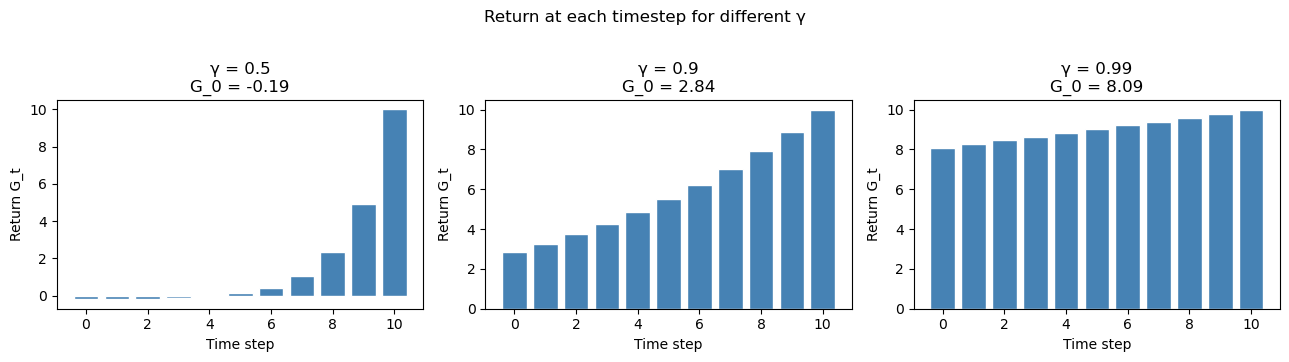

In [2]:
def compute_returns(rewards, gamma):
    """Compute discounted returns for a list of rewards (backwards pass)."""
    G = np.zeros(len(rewards))
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        G[t] = running
    return G

# Example trajectory: -0.1 per step, +10 at end
rewards = [-0.1] * 10 + [10.0]
t = np.arange(len(rewards))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, gamma in zip(axes, [0.5, 0.9, 0.99]):
    G = compute_returns(rewards, gamma)
    ax.bar(t, G, color='steelblue', edgecolor='white')
    ax.set_title(f'γ = {gamma}\nG_0 = {G[0]:.2f}')
    ax.set_xlabel('Time step'); ax.set_ylabel('Return G_t')
plt.suptitle('Return at each timestep for different γ', y=1.02)
plt.tight_layout(); plt.show()

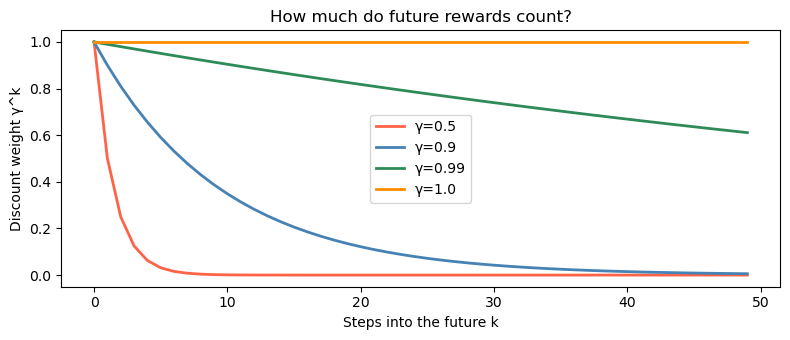


A reward 20 steps away is worth:
  γ=0.5: 0.0000 of its face value
  γ=0.9: 0.1216 of its face value
  γ=0.99: 0.8179 of its face value
  γ=1.0: 1.0000 of its face value


In [3]:
steps = np.arange(0, 50)
fig, ax = plt.subplots(figsize=(8, 3.5))
for gamma, color in [(0.5,'tomato'),(0.9,'steelblue'),(0.99,'seagreen'),(1.0,'darkorange')]:
    weights = gamma ** steps
    ax.plot(steps, weights, label=f'γ={gamma}', linewidth=2, color=color)
ax.set_xlabel('Steps into the future k')
ax.set_ylabel('Discount weight γ^k')
ax.set_title('How much do future rewards count?')
ax.legend(); plt.tight_layout(); plt.show()
print("\nA reward 20 steps away is worth:")
for g in [0.5, 0.9, 0.99, 1.0]:
    print(f"  γ={g}: {g**20:.4f} of its face value")

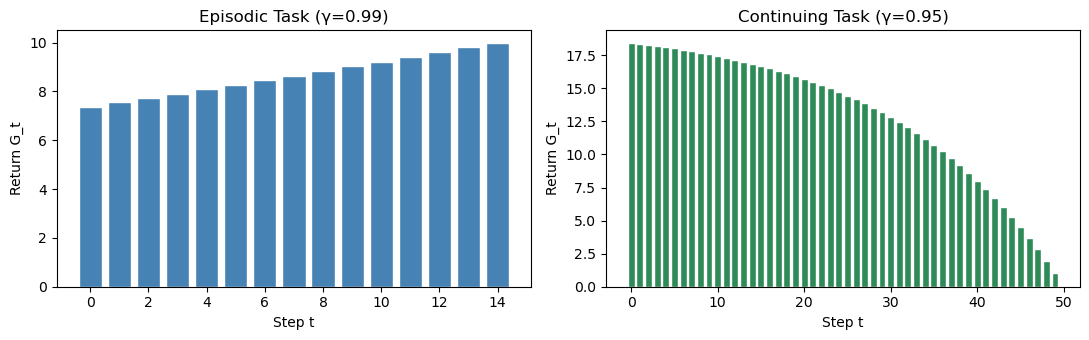

Continuing task: geometric series limit = R/(1-γ) = 20.0
Empirical G_0 = 18.46


In [4]:
# Episodic: trajectory has a natural end (e.g. reaching the goal)
def episodic_returns(n_steps=15, goal_reward=10.0, step_cost=-0.1, gamma=0.99):
    rewards = [step_cost] * (n_steps-1) + [goal_reward]
    return compute_returns(rewards, gamma)

# Continuing: no terminal state; must use discounting to keep G finite
def continuing_returns(n_steps=50, reward_per_step=1.0, gamma=0.95):
    rewards = [reward_per_step] * n_steps
    return compute_returns(rewards, gamma)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
g_ep = episodic_returns()
axes[0].bar(range(len(g_ep)), g_ep, color='steelblue', edgecolor='white')
axes[0].set_title('Episodic Task (γ=0.99)')
axes[0].set_xlabel('Step t'); axes[0].set_ylabel('Return G_t')

g_cont = continuing_returns()
axes[1].bar(range(len(g_cont)), g_cont, color='seagreen', edgecolor='white')
axes[1].set_title('Continuing Task (γ=0.95)')
axes[1].set_xlabel('Step t'); axes[1].set_ylabel('Return G_t')
plt.tight_layout(); plt.show()

print(f"Continuing task: geometric series limit = R/(1-γ) = {1.0/(1-0.95):.1f}")
print(f"Empirical G_0 = {g_cont[0]:.2f}")

In [5]:
rewards = np.random.randn(20)  # random rewards
gamma   = 0.9
G = compute_returns(rewards, gamma)

# Verify Bellman equation: G[t] == rewards[t+1] + gamma * G[t+1]
for t in range(len(G)-1):
    lhs = G[t]
    rhs = rewards[t] + gamma * G[t+1]
    assert np.isclose(lhs, rhs), f"Mismatch at t={t}: {lhs:.4f} vs {rhs:.4f}"
print("✅ Bellman equation verified for all timesteps")

✅ Bellman equation verified for all timesteps
